# **Statistical Analysis in Python:**

In [64]:
#Importing diffrent python modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df=pd.read_csv("Black Friday Data.csv")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [66]:
df.shape

(550068, 12)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [68]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [69]:
#Filling null values with zero
df=df.fillna(0)

In [70]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,0.0,0.0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,0.0,0.0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,0.0,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,0.0,0.0,7969


In [71]:
# Replaced '4+' with '4' in 'Stay_In_Current_City_Years
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '', regex=False)

In [72]:
# Converting Stay_In_Current_City_Years and product category columns to integer type
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)
df['Product_Category_1'] = df['Product_Category_1'].astype(int)
df['Product_Category_2'] = df['Product_Category_2'].astype(int)
df['Product_Category_3'] = df['Product_Category_3'].astype(int)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  int64 
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category_1          550068 non-null  int64 
 9   Product_Category_2          550068 non-null  int64 
 10  Product_Category_3          550068 non-null  int64 
 11  Purchase                    550068 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 50.4+ MB


# **T-test**

##**T-test to compare Average Purchase by Gender:**

In [74]:
from scipy.stats import ttest_ind

# Separate purchase data by gender
purchase_female = df[df['Gender'] == 'F']['Purchase']
purchase_male = df[df['Gender'] == 'M']['Purchase']

# Perform independent samples t-test
t_stat, p_value = ttest_ind(purchase_male, purchase_female)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    interpretation = "There is a statistically significant difference in average purchase amounts between genders."
else:
    interpretation = "There is no statistically significant difference in average purchase amounts between genders."

mean_male = purchase_male.mean()
mean_female = purchase_female.mean()

print(f"\nInterpretation:\n{interpretation}")
print(f"Average Purchase for Males: {mean_male:.2f}")
print(f"Average Purchase for Females: {mean_female:.2f}")
print(f"Difference in means (Male - Female): {mean_male - mean_female:.2f}")

T-statistic: 44.84
P-value: 0.000

Interpretation:
There is a statistically significant difference in average purchase amounts between genders.
Average Purchase for Males: 9437.53
Average Purchase for Females: 8734.57
Difference in means (Male - Female): 702.96


##**T-test to compare Average Purchase by Marital Status:**

In [75]:
from scipy.stats import ttest_ind

# Separate purchase data by marital status
purchase_unmarried = df[df['Marital_Status'] == 0]['Purchase']
purchase_married = df[df['Marital_Status'] == 1]['Purchase']

# Perform independent samples t-test
t_stat, p_value = ttest_ind(purchase_married, purchase_unmarried)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    interpretation = "There is a statistically significant difference in average purchase amounts between individuals with different marital statuses."
else:
    interpretation = "There is no statistically significant difference in average purchase amounts between individuals with different marital statuses."

mean_married = purchase_married.mean()
mean_unmarried = purchase_unmarried.mean()

print(f"\nInterpretation:\n{interpretation}")
print(f"Average Purchase for Married: {mean_married:.2f}")
print(f"Average Purchase for Unmarried: {mean_unmarried:.2f}")
print(f"Difference in means (Married - Unmarried): {mean_married - mean_unmarried:.2f}")

T-statistic: -0.34
P-value: 0.731

Interpretation:
There is no statistically significant difference in average purchase amounts between individuals with different marital statuses.
Average Purchase for Married: 9261.17
Average Purchase for Unmarried: 9265.91
Difference in means (Married - Unmarried): -4.73


# **ANOVA**

# **ANOVA to analyze spending differences across age group:**

In [76]:
from scipy.stats import f_oneway

# Group purchase amounts by Age category
age_groups = df.groupby('Age')['Purchase'].apply(list)

# Perform one-way ANOVA test
f_stat, p_value = f_oneway(*age_groups)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    interpretation = "There is a statistically significant difference in average purchase amounts among the age groups."
else:
    interpretation = "There is no statistically significant difference in average purchase amounts among the age groups."

print(f"\nInterpretation:\n{interpretation}")

# Print average purchase amount for each age group
mean_purchase_by_age = df.groupby('Age')['Purchase'].mean().sort_values(ascending=False)
print("\nAverage Purchase Amount by Age Group:")
print(mean_purchase_by_age.apply(lambda x: f'{x:.2f}'))

F-statistic: 40.58
P-value: 0.000

Interpretation:
There is a statistically significant difference in average purchase amounts among the age groups.

Average Purchase Amount by Age Group:
Age
51-55    9534.81
55+      9336.28
36-45    9331.35
26-35    9252.69
46-50    9208.63
18-25    9169.66
0-17     8933.46
Name: Purchase, dtype: object


# **ANOVA to analyze spending differences across city category:**

In [77]:
from scipy.stats import f_oneway

# Group purchase amounts by City_Category
city_groups = df.groupby('City_Category')['Purchase'].apply(list)

# Perform one-way ANOVA test
f_stat, p_value = f_oneway(*city_groups)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    interpretation = "There is a statistically significant difference in average purchase amounts among the city categories."
else:
    interpretation = "There is no statistically significant difference in average purchase amounts among the city categories."

print(f"\nInterpretation:\n{interpretation}")

# Print average purchase amount for each city category
mean_purchase_by_city = df.groupby('City_Category')['Purchase'].mean().sort_values(ascending=False)
print("\nAverage Purchase Amount by City Category:")
print(mean_purchase_by_city.apply(lambda x: f'{x:.2f}'))

F-statistic: 1130.75
P-value: 0.000

Interpretation:
There is a statistically significant difference in average purchase amounts among the city categories.

Average Purchase Amount by City Category:
City_Category
C    9719.92
B    9151.30
A    8911.94
Name: Purchase, dtype: object


                            Occupation  Stay_In_Current_City_Years  Purchase
Occupation                    1.000000                    0.030005  0.020833
Stay_In_Current_City_Years    0.030005                    1.000000  0.005422
Purchase                      0.020833                    0.005422  1.000000


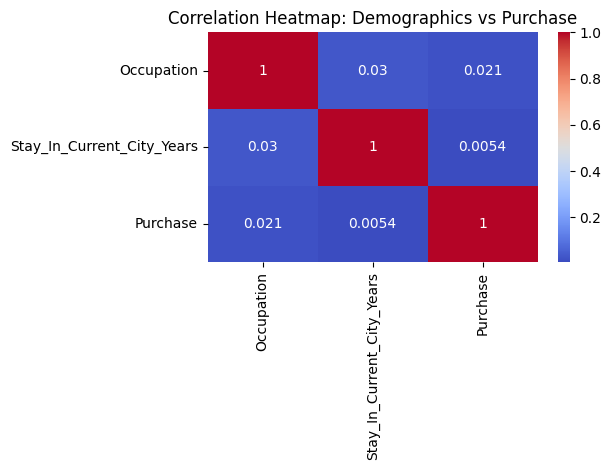

In [78]:
# correlation heatmap including occupation, city tenure and purchase
corr_cols = ['Occupation',
             'Stay_In_Current_City_Years',
             'Purchase']

corr_matrix = df[corr_cols].corr()
print(corr_matrix)

# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Demographics vs Purchase')
plt.tight_layout()
plt.show()

# **Based on the correlation matrix, here are the insights:**

**Very Weak Correlation with Purchase:** Both 'Occupation' and 'Stay_In_Current_City_Years' show extremely weak positive correlations with 'Purchase' (0.02 and 0.005, respectively). This suggests that there is almost no linear relationship between a person's occupation or the duration of their stay in the current city and the amount they spend.

**Minimal Inter-Variable Correlation:** The correlation between 'Occupation' and 'Stay_In_Current_City_Years' is also very weak (0.03), indicating these two demographic factors are largely independent of each other within this dataset.

# **Assumptions:**

**Each purchase is separate:** I assume each customer's purchase decision isn't directly affecting another's.

**Data spread is similar:** I assume the range of purchase amounts is roughly the same for each group I compare (males vs. females).

**Bell curve shape (ideally):** Ideally, the purchase amounts within each group would follow a bell-shaped curve. However, with a lot of data, these tests often still work well even if the curves aren't perfect.

# **Limitations:**

**Data quality matters:** Our results are only as good as the data we started with. If there were errors in recording, it could affect the outcome.

**Specific to this data:** These findings are from a specific 'Black Friday' dataset. They might not apply to other sales events, other stores, or all customers everywhere.

**Difference doesn't mean cause:** When I find a statistical difference (between genders), it means they tend to be different, but it doesn't automatically mean being male or female causes that difference.
